# Exercises 1

Data Blocking and Monte Carlo Methods

## Exercise 1.1

The exercise asks to evaluate the following integrals, using Monte Carlo; and then confront it with the analytical solution:

$$
\left\langle r \right\rangle = \int_0^1 r \mathrm{d}r = \frac{1}{2}
$$

$$
\int_0^1 (r - 1/2)^2 \mathrm{d} r = \frac{1}{12}
$$
We can evaluate the integral using Monte Carlo, we are interested in the value but we are also interested in evaluating the error of our prediction.

### Monte Carlo

In this exercise we will use the simplest implementation of Monte Carlo methods for evaluating an integral. We start by defining the generic integral:

$$
\left\langle f(r) \right\rangle := \int_a^b f(r) \mathrm{d}r
$$

Where $f(r)$ is a function of some variables $r$, in our exercise $f := r : \mathbb{R} \mapsto \mathbb{R}$.

The real power of Monte Carlo methods comes for high dimensionality, difficult (or impossible) to analytically solve functions. There are some drawbacks, we cannot evaluate functions with infinite variance, in this case the error we are making gets bigger and not smaller if we increase the number of samples.

### Data Blocking Method

To evaluate the error we cannot use the standar deviation on every function $f$. But the Central Limit Theorem states that if we have a function $f$ with *finite* variance, and we take the average of $f$, then the averages $\left\langle f \right\rangle$ are normally distributed around the true value. And we can evaluate the error by calculating the standar deviation on the averages.

Numerically, we define a *block* the process where we calculate one average: 
$$
A := \left\langle f \right\rangle_j = \frac{1}{N} \sum_{i = 1}^N f(r_i)
$$
Where $r_i$ is sampled from the uniform distribution on the integral domain, and $j$ is the $j$-th block.

The final value of our integral will be the average of the $M$ blocks.
$$
\left\langle A \right\rangle_j \mu = \frac{1}{M} \sum_{j = 1}^M A_j
$$

The error on this value is simply the variance of the gaussian distribution, defined as the second central moment:
$$
\varepsilon^2 = \frac{\sigma^2}{M - 1} := \frac{1}{M -1} \left(\left\langle A^2 \right\rangle - \left\langle A \right\rangle^2\right) =
 \frac{1}{M -1}\left [\frac{1}{N}\sum_{i=1}^N A_i^2 - \left(\frac{1}{N}\sum_{i=1}^N A_i \right)^2 \right]
$$
Where we have divided by a factor of $M -1$ since we are evaluating the error of the sample mean value.

So to estimate the concurrent error we just need to track: the average of averages, the average of squared averages, and the number of blocks calculated (also we need the number of samples in each block, which is constant).

In [137]:
from cycler import cycler

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.stats import chi2

import scienceplots


plt.style.use(["science", "ieee"])

colors = plt.cm.Pastel1.colors
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)

In [138]:
def plot_integral(filename: str, expected_value: float) -> None:
    data = np.loadtxt(filename)

    blocks = np.arange(data.shape[0])
    averages = data[:, 0]
    errors = data[:, 1]

    plt.errorbar(blocks, averages, errors, label="Simulation")
    plt.plot(blocks, expected_value * np.ones_like(blocks), label="Expected")

    plt.xlabel("Number of blocks")
    plt.ylabel("Mean Value of the integral")

    plt.legend()
    plt.grid(True)

    plt.plot()

Here we evaluate the integral $\int_0^1 r \mathrm{d}r$.

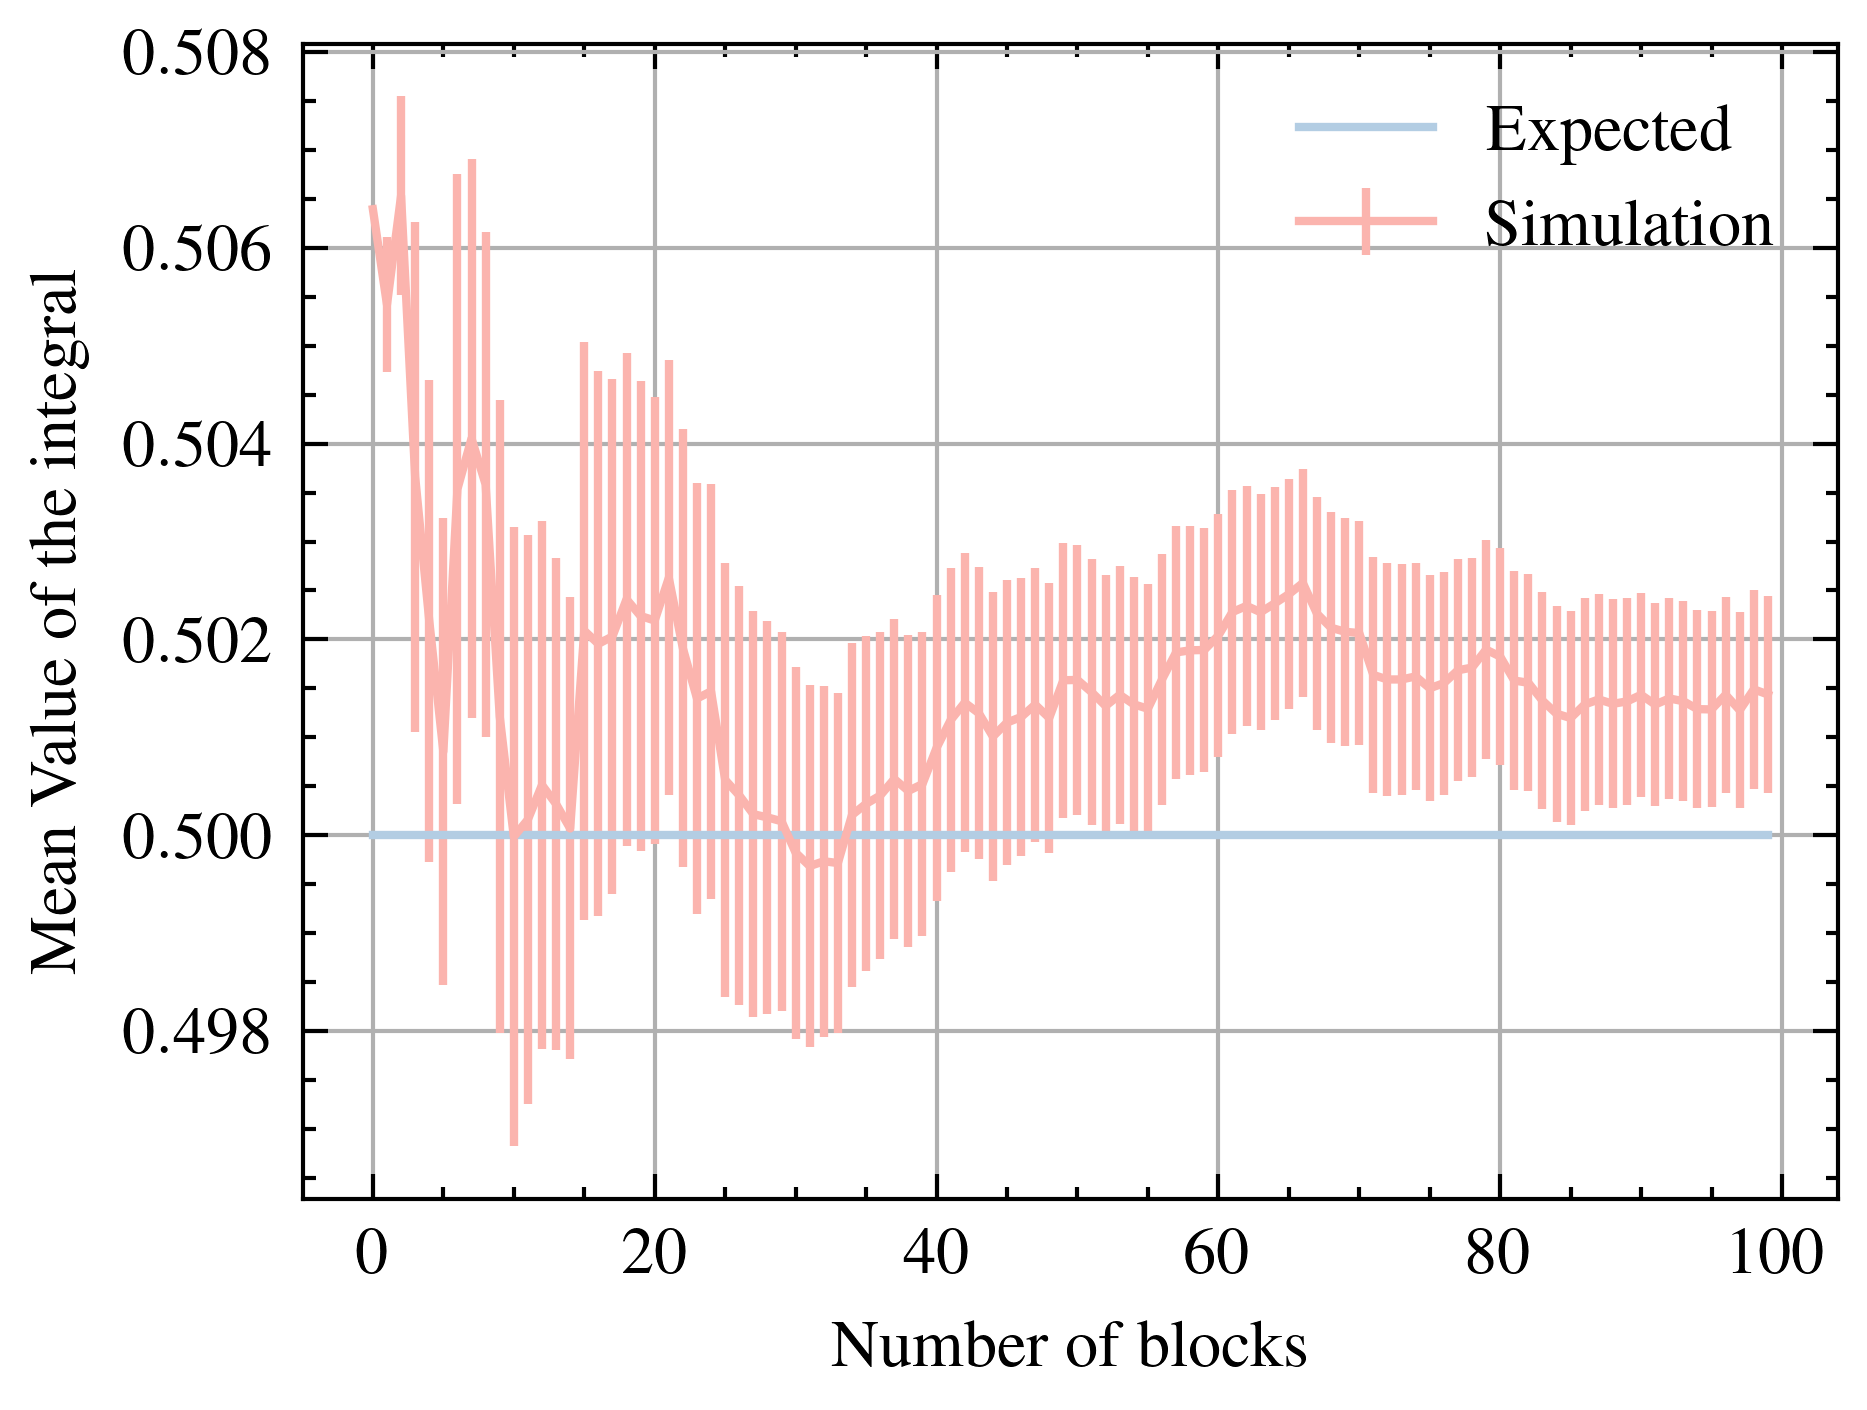

In [139]:
plot_integral("../Exercises/Exercises_01/Exer_01_01/integral_1.dat", 0.5)

And we can do the same for $\int_0^1 (r - 1/2)^2 \mathrm{d} r$

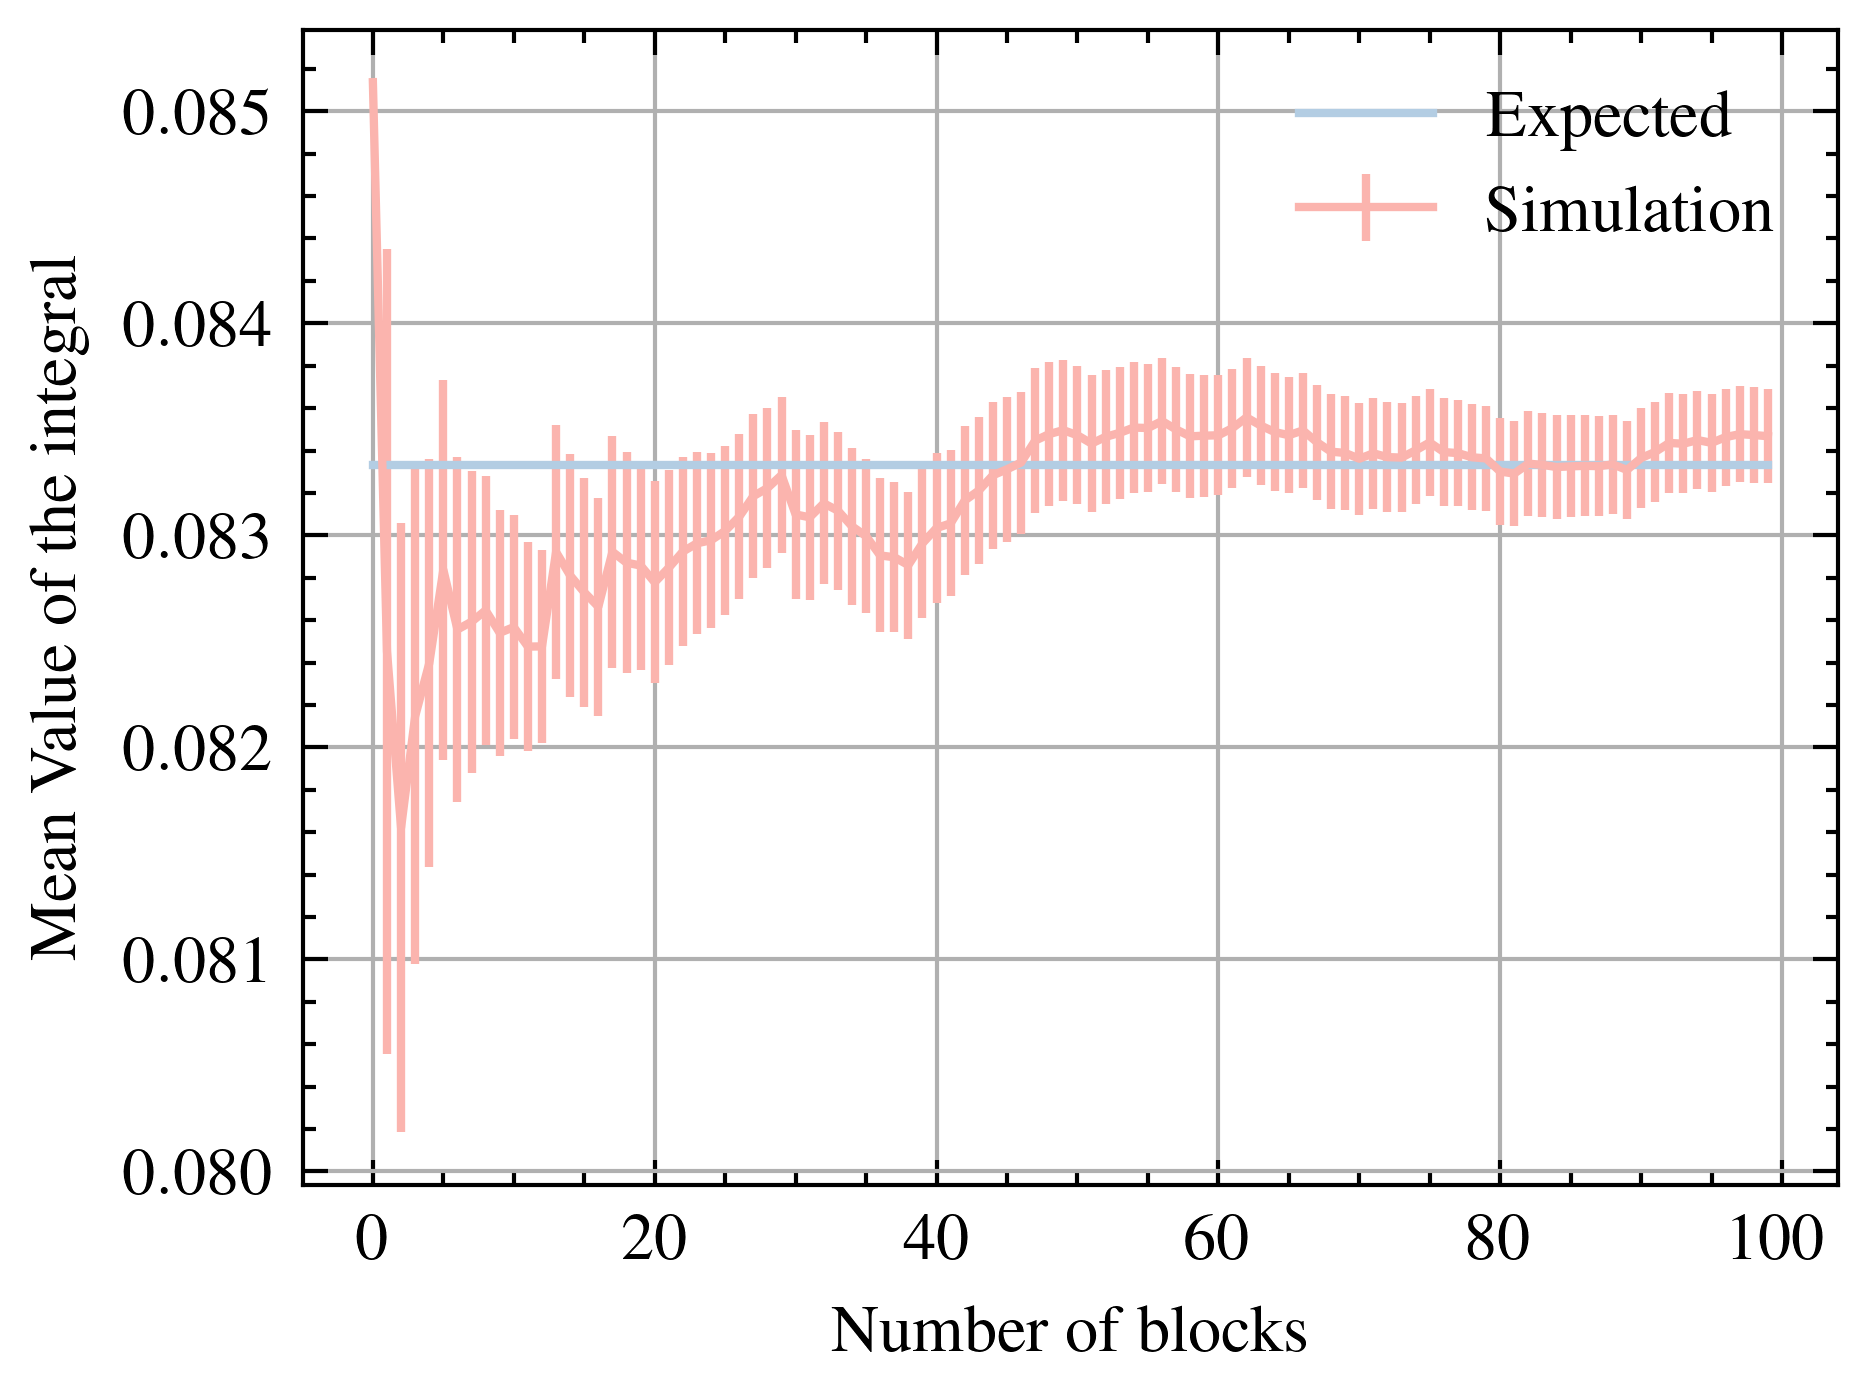

In [140]:
plot_integral("../Exercises/Exercises_01/Exer_01_01/integral_2.dat", 1 / 12)

As we expect we found the simulation value near the expected value, since the value is gaussian we can expect to find it 68.3% of times in one sigma.

### Evaluating the goodness of the distribution

We have assumed that $r$ was drawn from a uniform distribution, but in reality we are using pseudo-random numbers, not really random numbers!.

This could be an issue if we find that out pseudo-number generator is not a good approximation of a random number generator, to test this we need to estimate the probability that $r$ are not drawn from a uniform distribution, if this probability is low we can assume the estimator is good enough for our pourposes.

To evaluate this, we can implement the $\chi^2$ test, dividing the range where we sample $r$ in subsets, each sample will have a probability to be inside or outside one predetermined subset, we evaluate this for multiple samples and for all subsets. This will give us the binomial distribution for each subset.

We recall that the binomial distribution is the probability of finding $k$ success samples (each with probability $p$) in $n$ trials.
$$
P_\text{binomial} (X = k) = \binom{n}{k} p^k (1 - p)^{n - k}
$$
The average of the binomial distribution is $\langle X \rangle = np$.

Then the $\chi^2$ test can be evaluated using Pearson's formula:
$$
\chi^2 \simeq \sum_{i = 1}^{L}\frac{\left( O_i - E_i \right)^2}{E_i}
$$
Where $E_i = np$ is the expected value, $O_i$ is the observed value and $L$ is the number of subsets.

If we divide the range $[0, 1)$ in $L = 100$ subsets of equal length we have that $p = 1 / L$ and we expect to find $\chi^2 \simeq 100$.

In [166]:
def chi_sqrd(filename):
    chi2i = np.loadtxt(filename)

    print(f"chi^2 ~ {np.mean(chi2i)}")

    plt.hist(chi2i, bins="auto", density=True, label="Data")

    x = np.linspace(0, np.max(chi2i), 100)
    y = chi2.pdf(x, df=99)
    plt.plot(x, y, label=r"$\chi^2$ with $k = 99$")

    plt.xlabel(r"Value of $\chi^2_i$")
    plt.ylabel(r"Number of $\chi^2_i$ in the range")

    plt.legend()
    plt.grid(True)

    plt.show()

chi^2 ~ 98.78560000000002


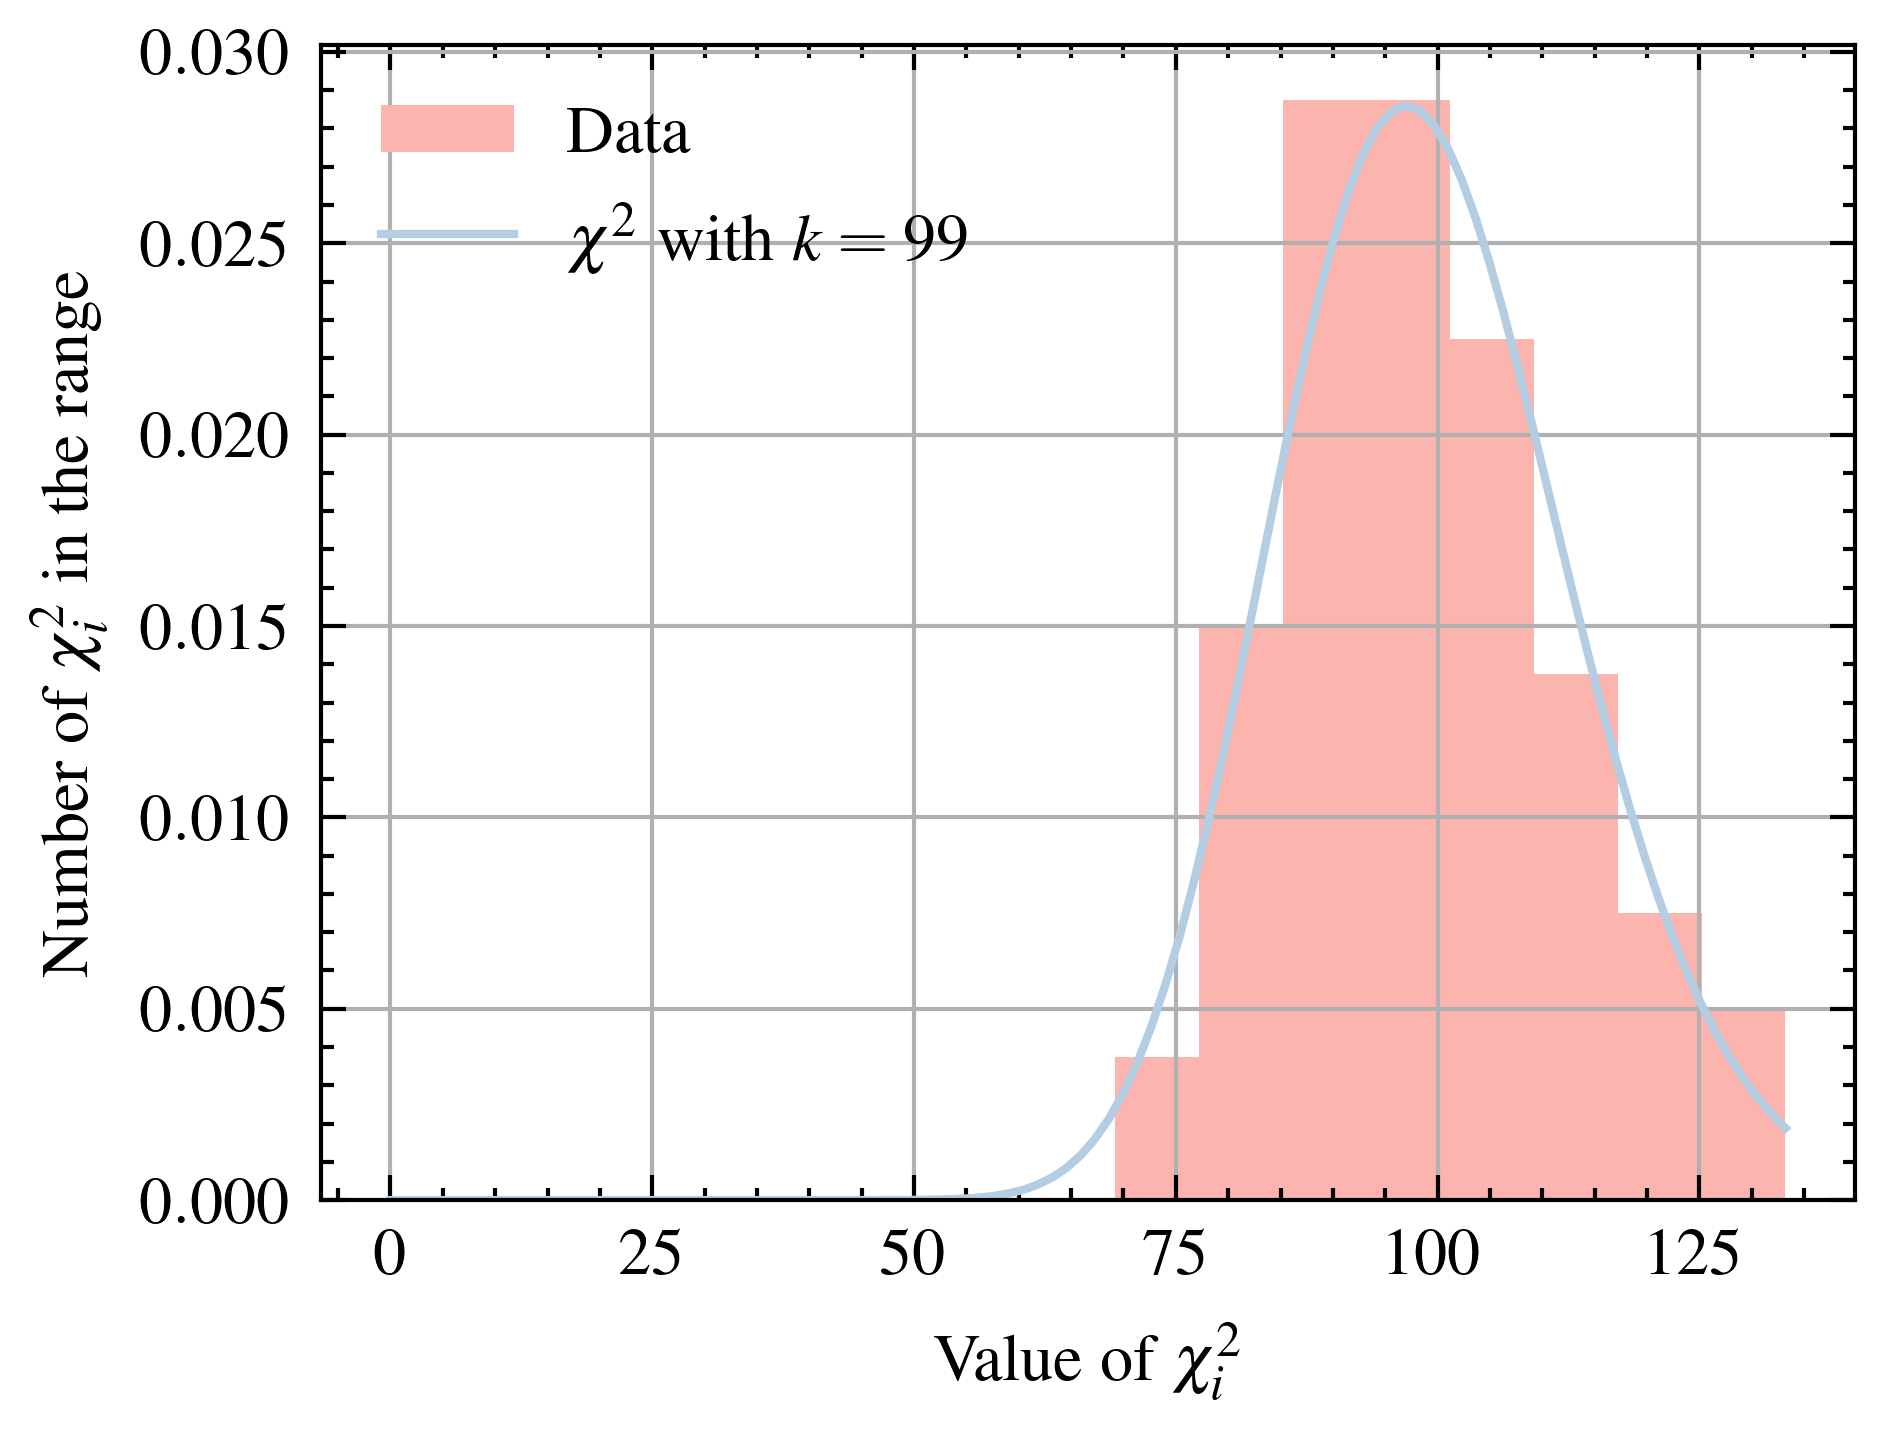

In [167]:
chi_sqrd("../Exercises/Exercises_01/Exer_01_01/chi_sqrd.dat")

## Exercise 1.2

In this exercise we are asked to extend the NSL pseudo-random number generator, with two distributions and then check the Central Limit Theorem.

The distributions we are asked to implement are the exponential distribution and the Cauchy-Lorentz distribution.

### Exponential distribution
The probability density function is defined as:
$$
p[\lambda](x) = \lambda \exp(-\lambda x) 
$$

To generate a random number with this distribution we can generate a random number $y$ in the range $[0, 1)$ and invert the cumulative density function, the last one is:
$$
y = \text{CDF} = 1 - e^{-\lambda x} 
$$

So inverting the CDF we get:
$$
x = - \frac{1}{\lambda}\ln(1 - y)
$$

Using this method we were able to extract a new probability density function, at the same cost (except for a constant) of generating a random number using a uniform density function. I would like to underline that the CDF must be invertible to use this method, if the CDF is not invertible we cannot use this method to generate its probability density function.

### Cauchy-Lorentz distribution
We follow the same logic as the previous distribution, the PDF is:
$$
p[\mu, \Gamma](x) = \frac{1}{\pi} \frac{\Gamma}{(x - \mu)^2 + \Gamma}
$$

Its CDF is:
$$
y = \text{CDF} = \frac{1}{\pi} \arctan\left(\frac{x-\mu}{\Gamma}\right)+\frac{1}{2}
$$
By inversion we get:
$$
x = \Gamma \tan\left(\pi(y - 1/2)\right) + \mu
$$

### Central Limit Theorem

We are then asked to check the Central Limit Theorem using data blocking, for three distributions: uniform, exponential and Cauchy-Lorentz; for each distribution we are asked to make a figure with different block sizes: 1, 2, 10, 100 samples per block. 

For the Central Limit Theorem we know that for a finite variance density function increasing the number of samples per block leads to the gaussian density function. But we can also generalize the Central Limit Theorem to infinite variance density functions, for those functions we converge to other probability density functions. In particular for a Cauchy-Lorentz we get the Cauchy-Lorentz density function.


# ???
maybe add something explaining: 
$$
p(x) \sim \frac{1}{|x|^{1+\alpha}}
$$

In [143]:
def plot_pdf(filename):
    # dist = dist.lower()
    # if dist not in ["gauss", "lorentz"]:
    #     raise ValueError("Invalid distribution name, valid options are: gauss, lorentz")

    samples = [1, 2, 10, 100]

    data = np.loadtxt(filename)

    fig, axs = plt.subplots(1, 4, figsize=(12, 4))

    for i in range(4):
        axs[i].hist(data[:, i], bins="auto", density=True, label="Data")

        # if i == 3:
        #     x = np.linspace(np.min(data[:, i]), np.max(data[:, i]), 1000)
        #     y = gaussian(x) if dist == "gauss" else lorentzian(x)

        #     axs[i].plot(x, y, label="Expected")

        #     axs[i].legend()

        axs[i].set_title(f"{samples[i]} Samples")
        axs[i].grid(True)

        # if dist == "lorentz":
        #     axs[i].set_xlim((-100, 100))

    plt.show()

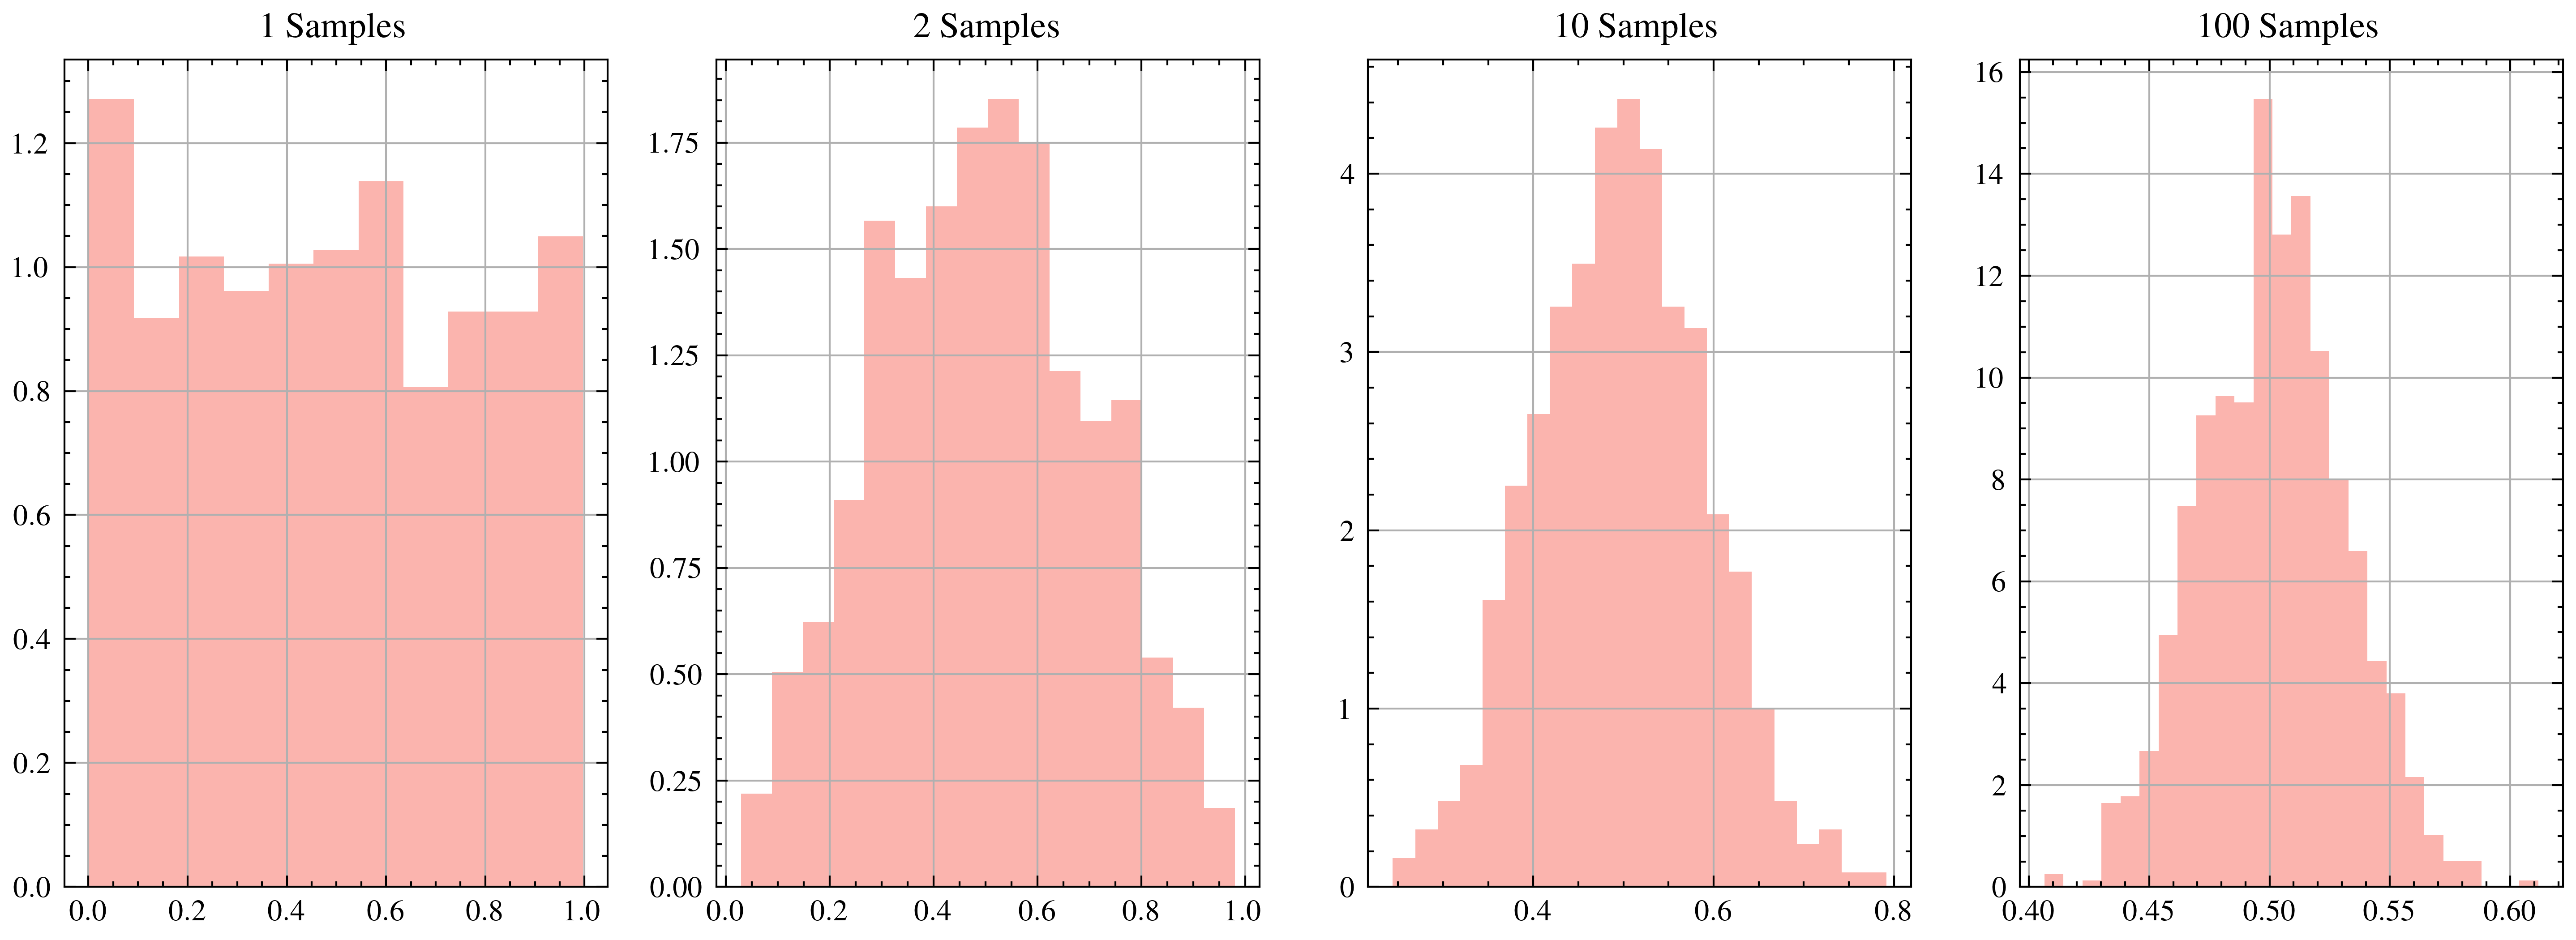

In [144]:
plot_pdf("../Exercises/Exercises_01/Exer_01_02/uniform.dat")

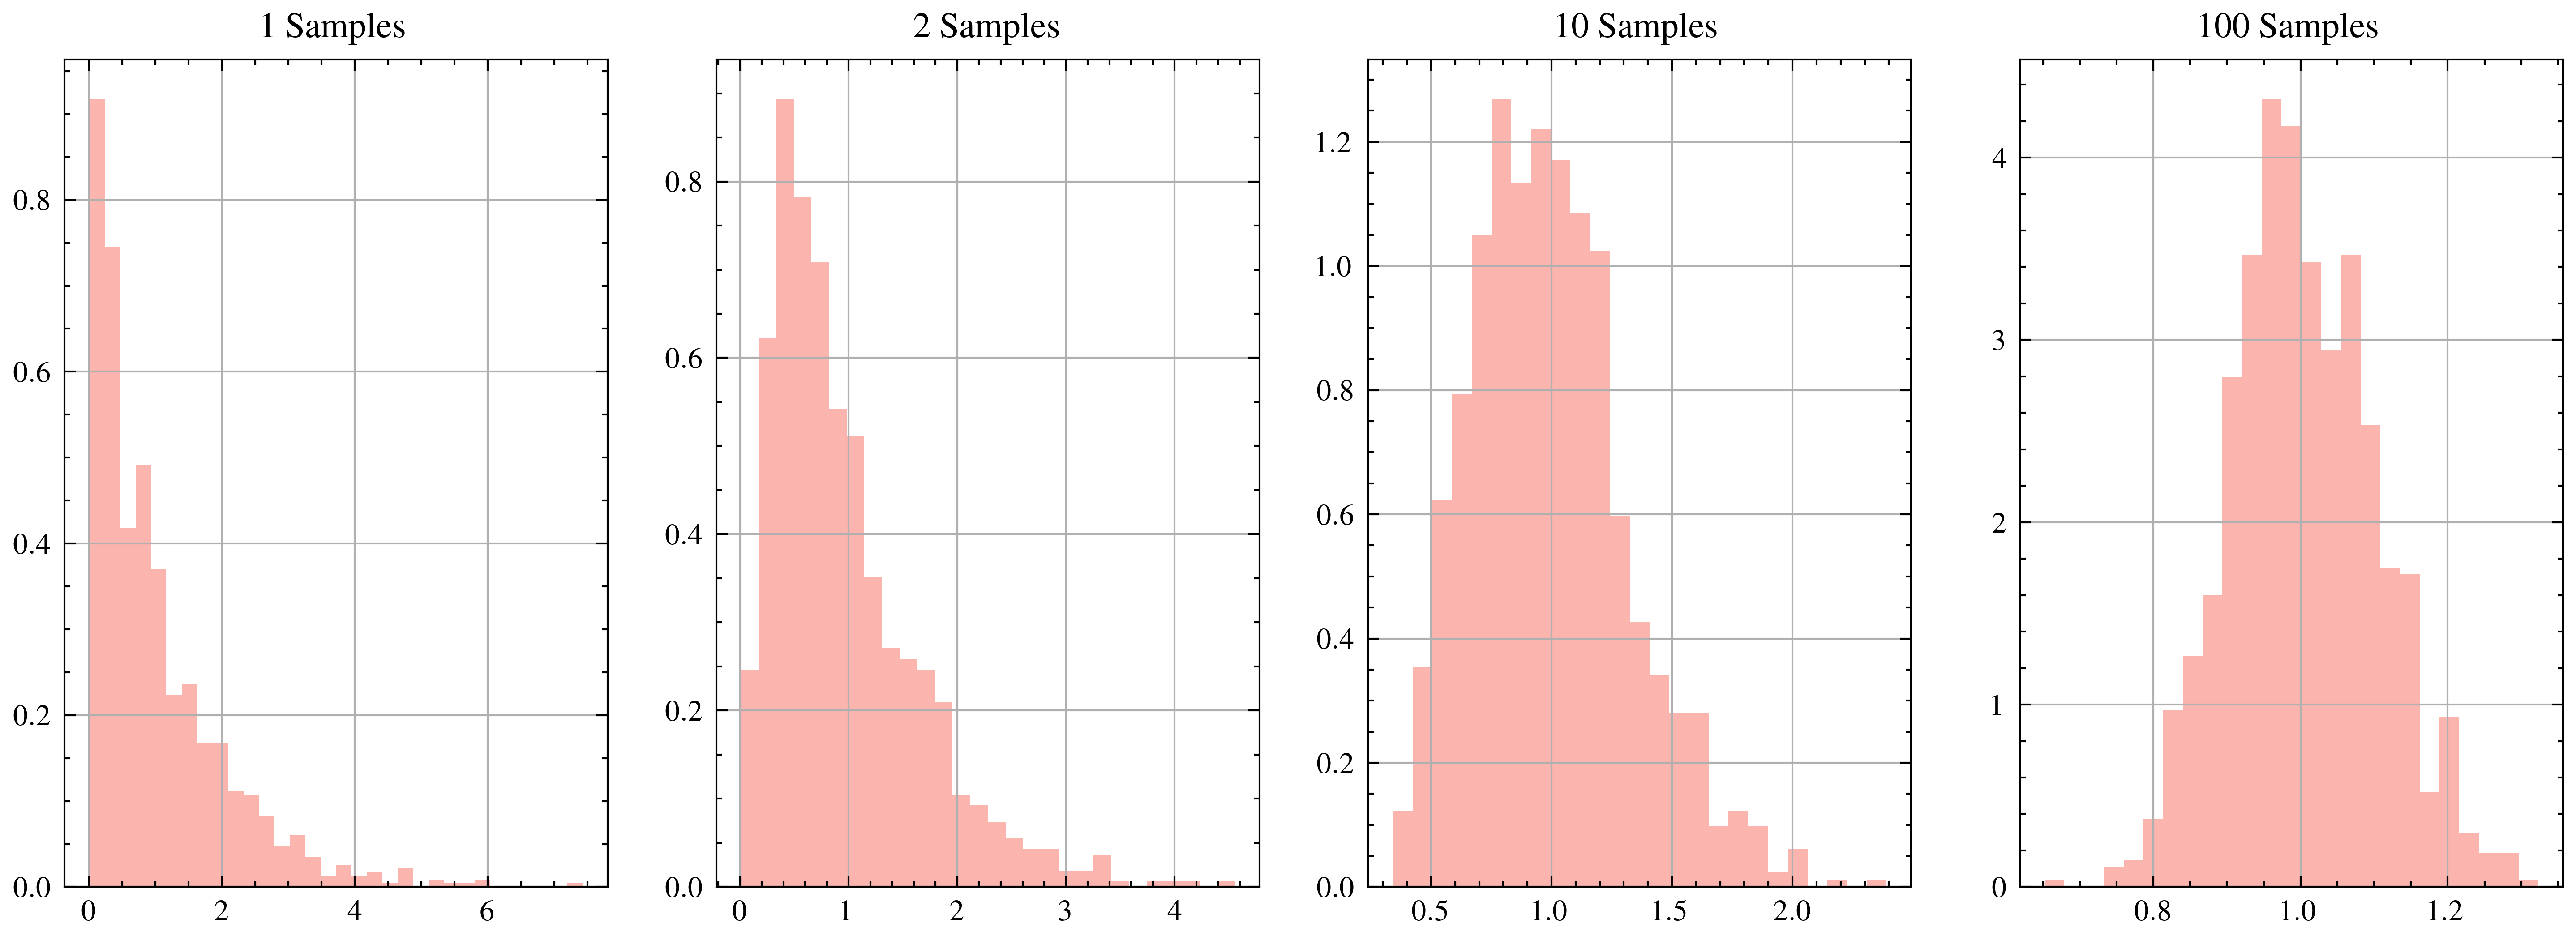

In [145]:
plot_pdf("../Exercises/Exercises_01/Exer_01_02/exponential.dat")

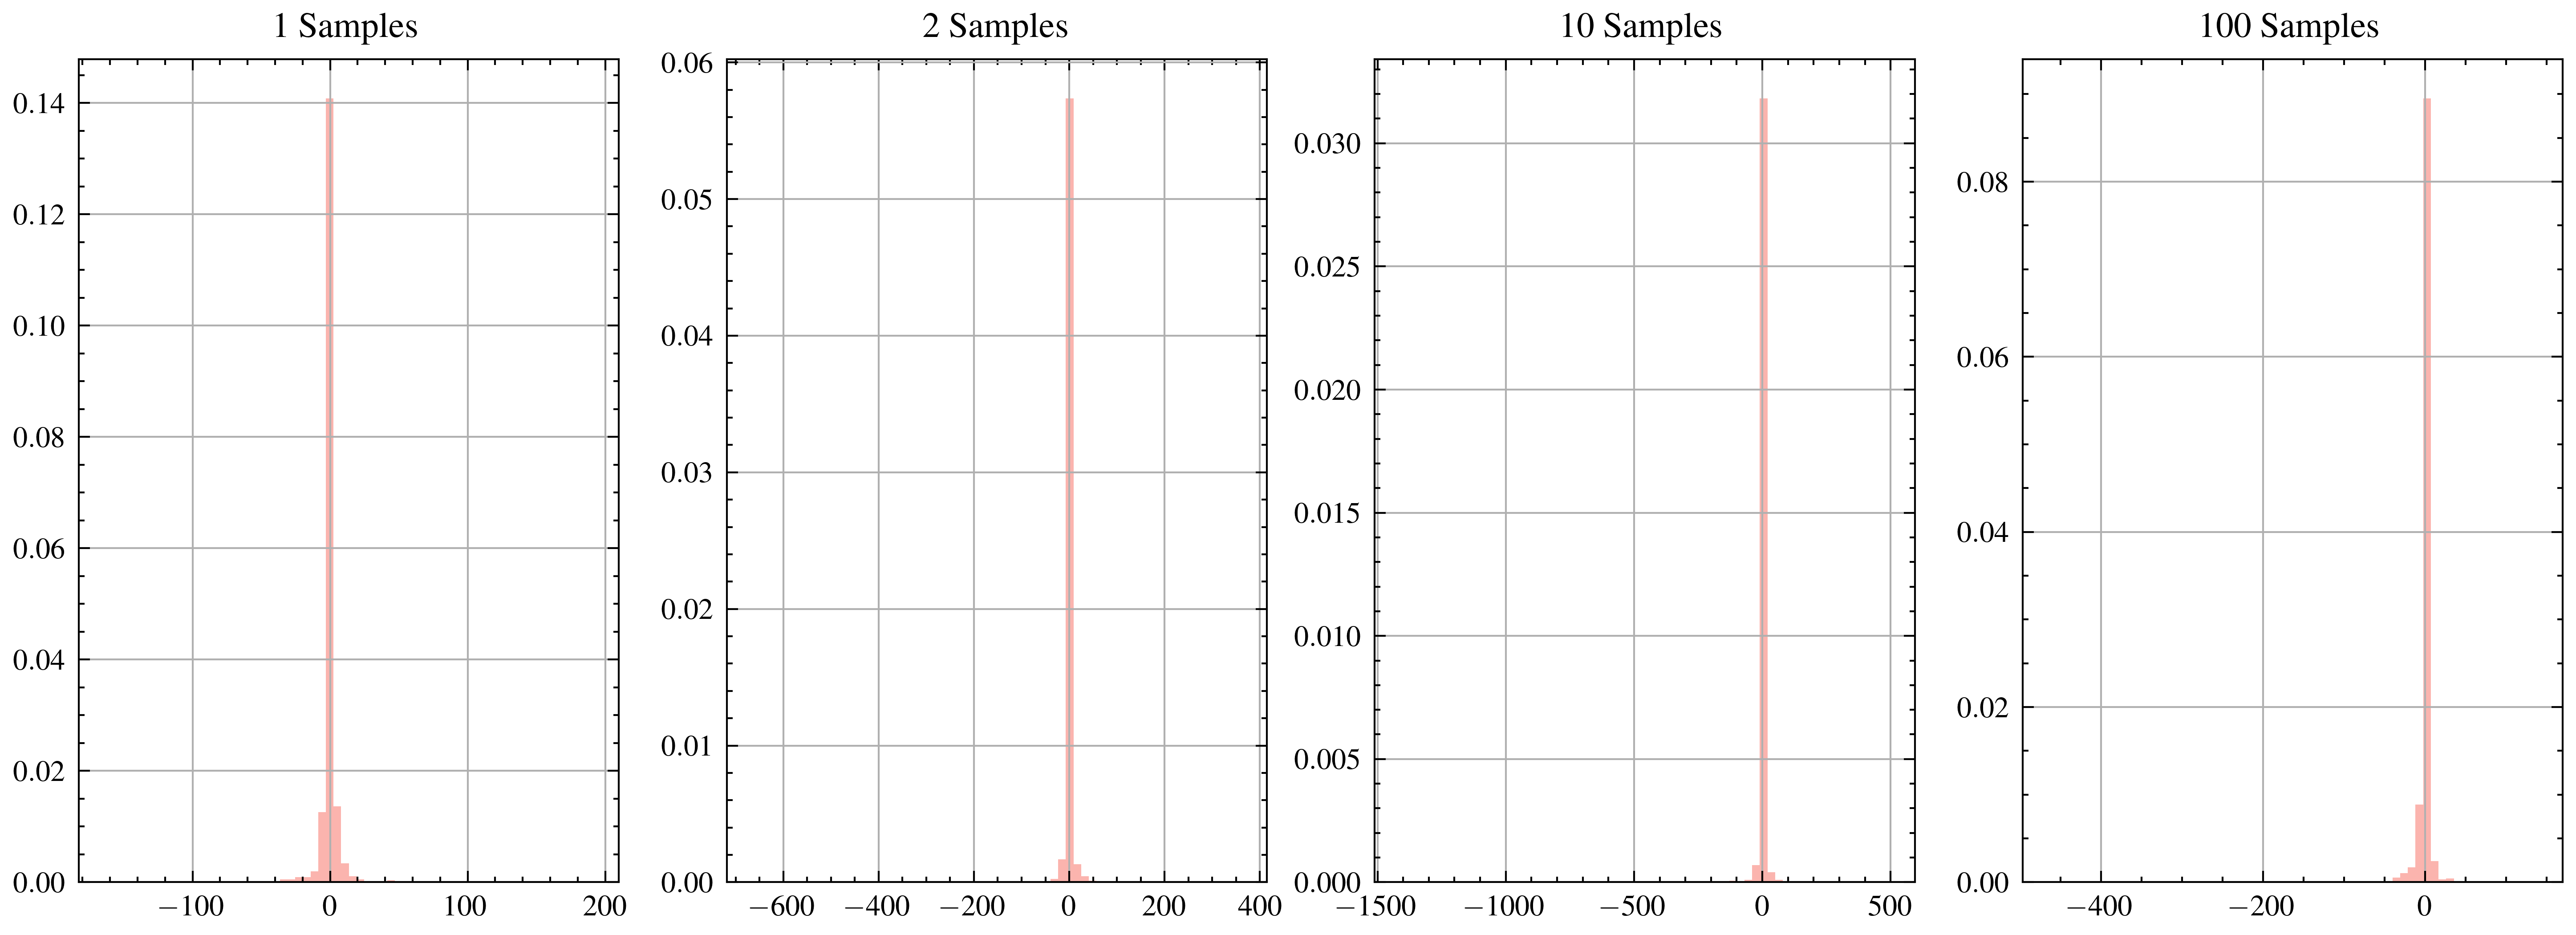

In [146]:
plot_pdf("../Exercises/Exercises_01/Exer_01_02/lorentz.dat")

As expected we can see that for 100 samples the uniform and exponential distributions converge to the gaussian, and the cauchy-lorentz converges to the cauchy-lorentz.

## ???
Add the fit?

# Exercise 1.3

We are asked to simulate the Buffon's experiment ([Wikipedia link](https://en.wikipedia.org/wiki/Buffon%27s_needle_problem)) to approximate the value of $\pi$, the probability that a needle will interect one line is $P = 2L / \pi d$. We can calculate the probability $P = \lim_{N\to\infty} \frac{N_\text{hits}}{N_\text{throws}}$, then the value of $pi$ is calculated as:
$$
\pi = \lim_{N\to\infty} \frac{N_\text{hits}}{N_\text{throws}} \frac{2L}{d}
$$
where $L$ is the needle length and $d$ is the distance between lines. We need to make the assumpion that $L < d$ so we don't hit multiple lines, also it is important to not use $L \ll d$ because in that way $P \ll 1$ and the process becomes slow to converge.

![BuffonNeedleExperiment](../Media/Exercises_01/BuffonNeedle_700.svg)
Image of the Buffon Needle Experiment, taken from: [Wolfram Mathworld](https://mathworld.wolfram.com/BuffonsNeedleProblem.html).

## Numerical Method

To implement the method we need to construct a grid, with parallel lines, generate two points at distance $L$ to build the needle, and check if the needle overlaps any line.

### Optimizations

The lines must be parallel, but there is no preference in their direction, from now we will consider them horizontal. This gives us the possibility to discard the $x$ position of the points, because the problem is translation invariant on the $x$ axis, we just need to check if the $y$ values of the two points have one line in between.

We can also use the **discrete** translation invariance on the $y$ axis, to reduce the size of the plane from infinite to size $d$, that's because we don't care which line is crossed but only if one is crossed. So when we generate a point $(x_1, y_1)$ we can translate $y_1$ to a reference line, and consider only the line below and above, then generate a point $(x_2, y_2)$ in the circle with radius $L$ centered in the previous point $(x_1, y_1)$, and just check if the needle crosses the line below or above. 

In this way we don't need the $x$ values, and we know that $0 <= y_1 < d$ (generated by a uniform distribution), and $-d < -L <= y_2 < d + L < 2d$ (generated from $y_1$ plus a sinusoidal distribution restricted to the first oscillation), so we just need to do two checks, if $y_2 < 0$ and if $y_2 > d$.

There could have been another optimization. We have generated $y_2 = y_1 + L sin(\theta)$ with $\theta \in \mathcal(U)[0, 2\pi)$ uniform distributed. But if we restrict to $\theta \in \mathcal(U)[0, \pi)$, then the value of $y2$ is also restricted to $0 <= y_2 < d + L$, and we would just need to do one check: if $y_2 > d$. This last optimization was not implemented in the code.

### Generating $y_2$ without $\pi$

As stated previously we generate $y_2 = y_1 + L sin(\theta)$, but for $\theta$ we need to know the value of $\pi$. 

We can avoid this problem using *accept-reject* methods, we generate a random point $(x, y)$ in the unit square, if it is not also inside the unit circle we reject this point and generate another; if it is inside the unit circle we normalize the value to 1 and get two independent values, one for $x = \cos\theta$ and one for $y = \sin\theta$. 

In our code we use $\sin\theta = \frac{y}{\sqrt{x^2 + y^2}}$.

[]

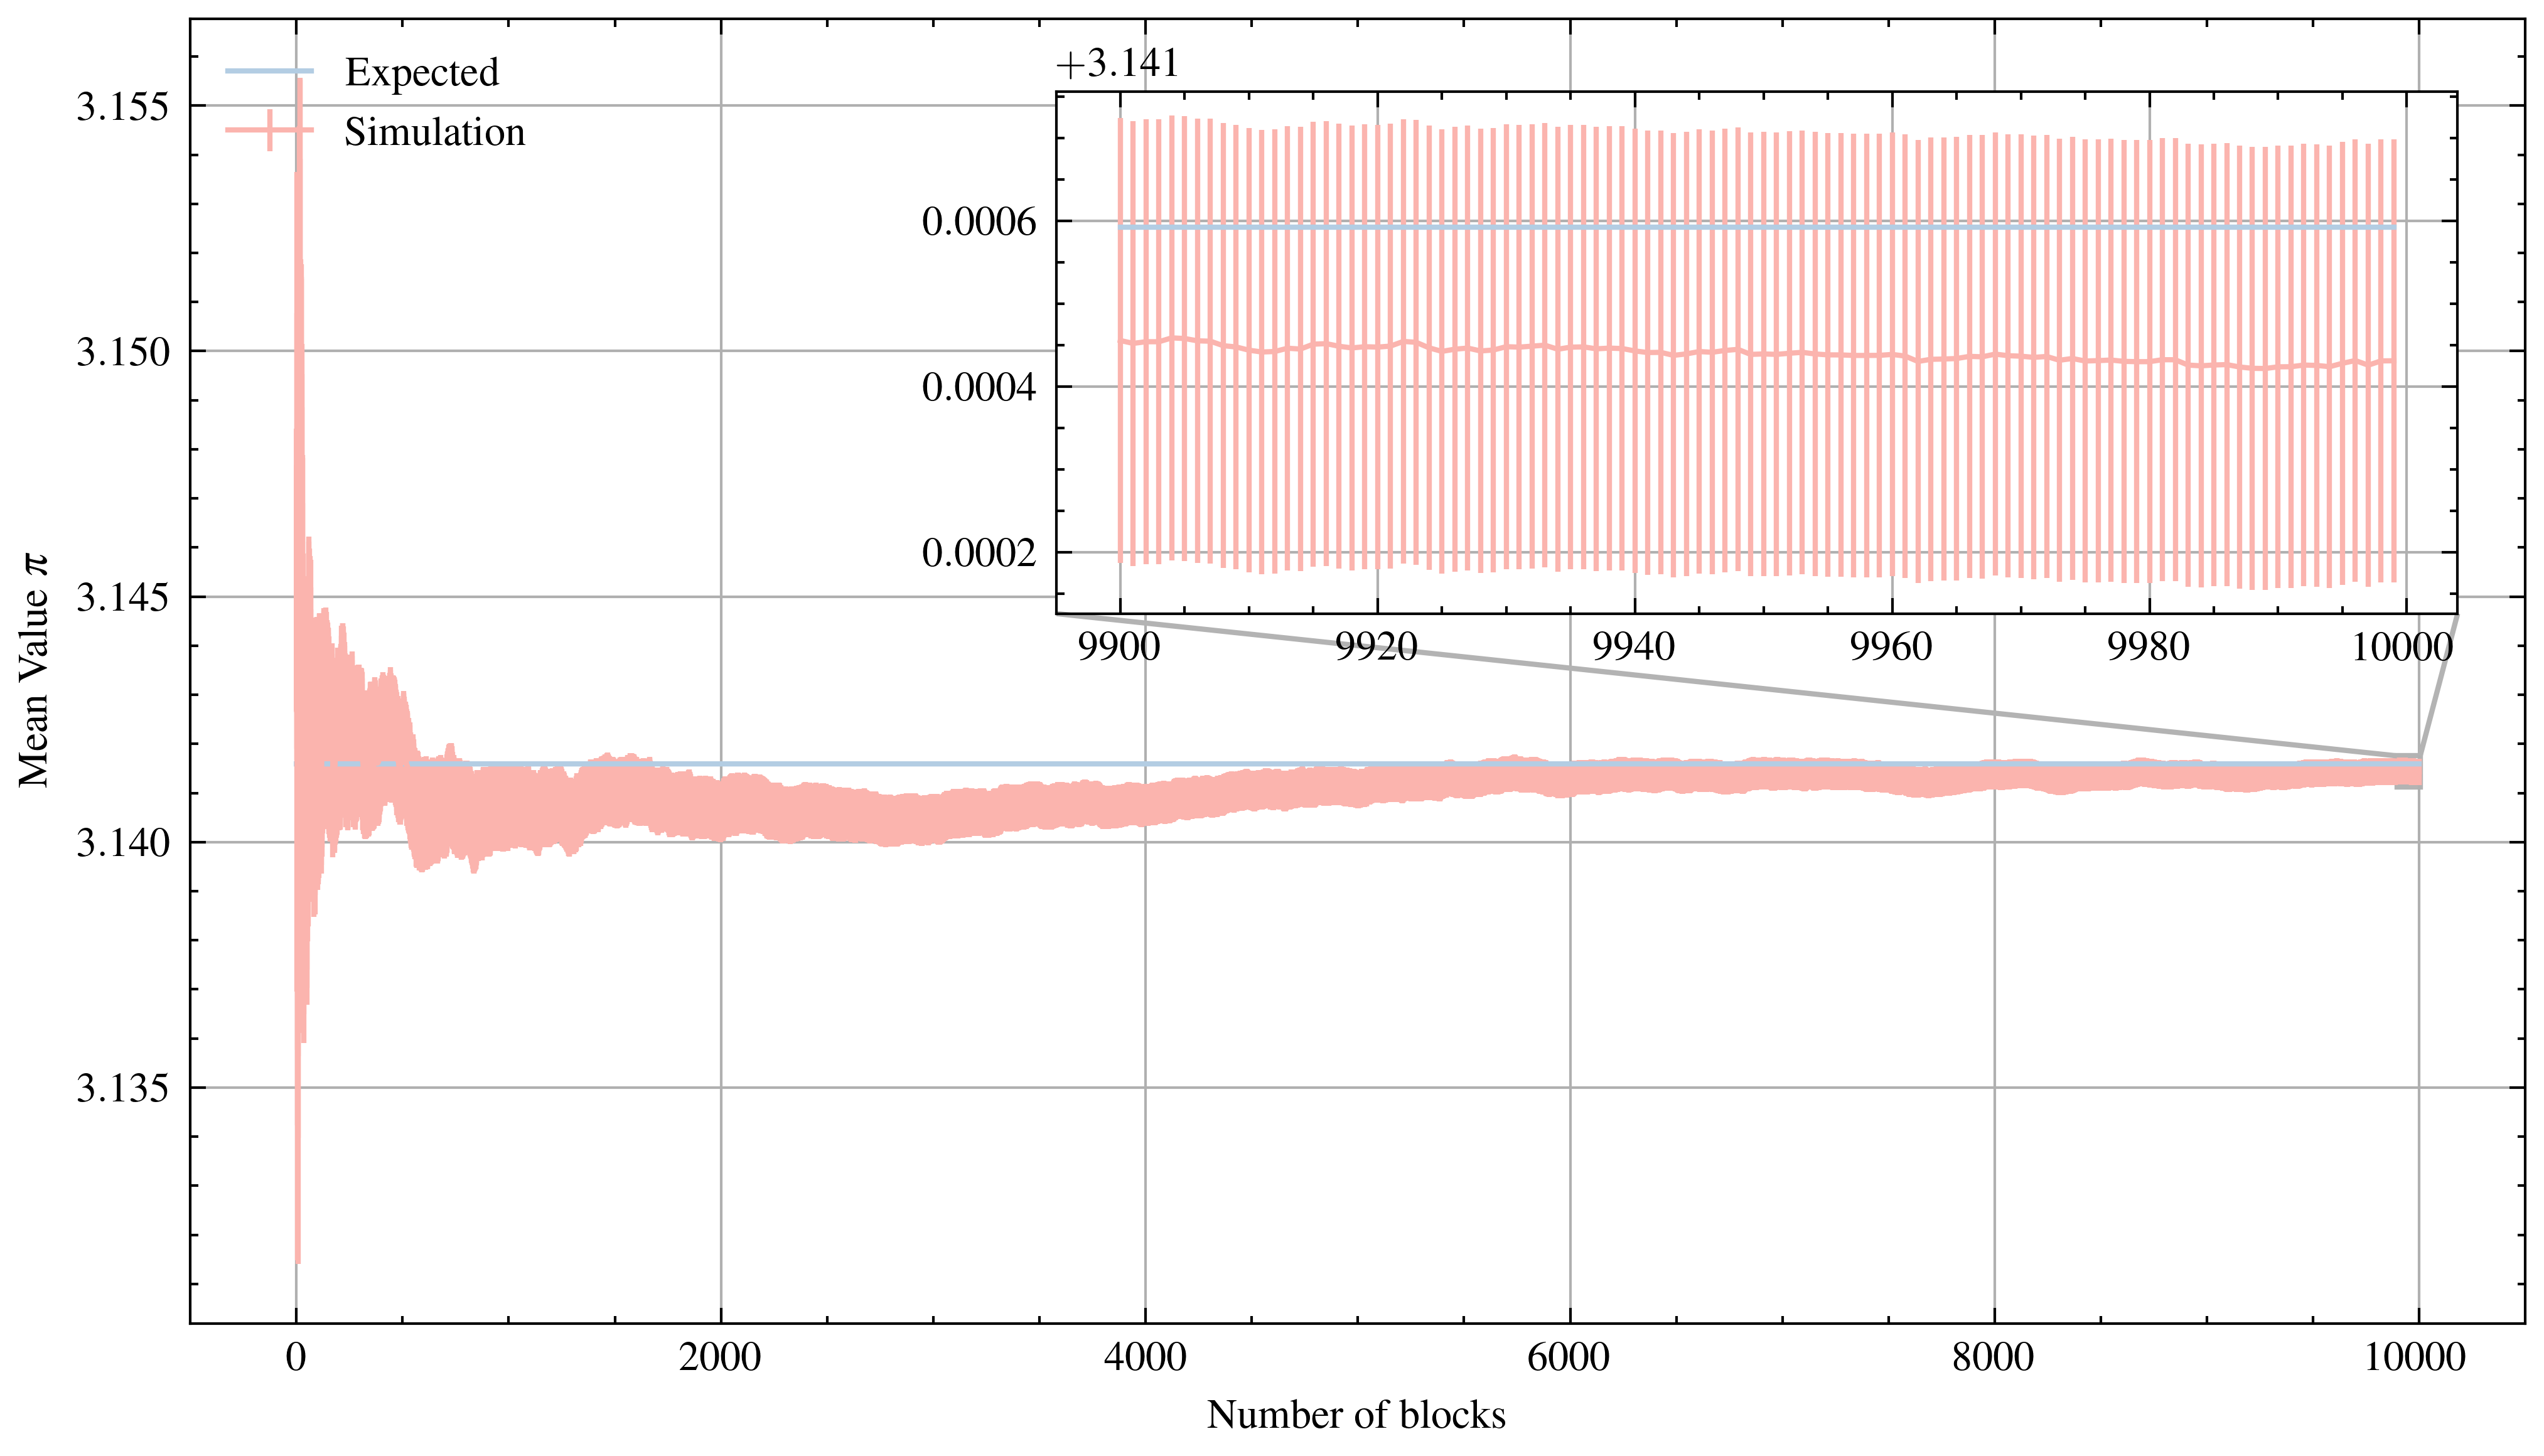

In [172]:
# fetch and clean data
data = np.loadtxt("../Exercises/Exercises_01/Exer_01_03/pi.dat")

blocks = np.arange(data.shape[0])
averages = data[:, 0]
errors = data[:, 1]

# plot
fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))

ax.errorbar(blocks, averages, errors, label="Simulation")
ax.plot(blocks, np.pi * np.ones_like(blocks), label="Expected")

# inset plot
axins = inset_axes(
    ax,
    width="60%",
    height="40%",
    loc="upper right",
    bbox_to_anchor=(-0.02, -0.04, 1, 1),
    bbox_transform=ax.transAxes,
)

axins.errorbar(blocks[-100:], averages[-100:], errors[-100:])
axins.plot(blocks[-100:], np.pi * np.ones(100))

patch, pp1, pp2 = mark_inset(ax, axins, loc1=1, loc2=1, ec="0.7")
pp1.loc1, pp1.loc2 = 3, 2  # adjust the position of the left line
pp2.loc1, pp2.loc2 = 4, 1  # adjust the position of the right line

# style
ax.set_xlabel("Number of blocks")
ax.set_ylabel(r"Mean Value $\pi$")

ax.legend(loc="upper left")
ax.grid(True)
axins.grid(True)

plt.plot()